In [3]:
# parent_folder_path = "/Users/haleyoro/Desktop/" # work on library computer
parent_folder_path = "/Users/Haley/Desktop/" # work on local computer

In [4]:
# !pip3 install pyabf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
from waveforms_helpers2 import *
import pickle
from center_vrb import *
from vrb_plotbouts import *

## Notebook Roadmap\n
1. Configure paths and load metadata/ABFs.\n
2. Use helper functions imported from `finalwaveform_processor_functions.py`.\n
3. Run waveform extraction and binning.\n
4. Compute grouped averages and generate plots.\n
5. Export outputs.

In [5]:
# Helper functions are maintained in a separate module for readability\n
from finalwaveform_processor_functions import *
print("Loaded helper functions from finalwaveform_processor_functions.py")

Loaded helper functions from finalwaveform_processor_functions.py


In [8]:
cell_types_df = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Cleaned, updated files from Spring/summary_spikes2.csv")

cell_types_df.reset_index(drop=True,inplace=True)
cell_types_df

,Cell,currents,vrb,group,cell attached,Cell Type,Input Resistance,mean,median,min,max,total spikes,tags
0,2012_08_01_cell1,0,1,Low Rin Secondary,NaN,vSMN,287.00,24.97,24.52,18.47,38.55,41,yes
1,2012_08_01_cell3,0,1,Primary,NaN,MiP,49.99,42.55,42.84,29.46,52.69,65,yes
2,2012_08_07,0,1,Low Rin Secondary,NaN,vSMN,219.00,24.88,28.92,0.38,38.93,81,no
3,2012_08_31_cell1,1,2,Primary,NaN,MiP,45.33,39.28,38.40,26.93,52.55,64,yes
4,2012_08_31_cell2,0,2,Primary,NaN,vRoP,44.77,38.21,39.15,24.64,48.71,69,yes
5,2012_08_31_cell3,0,2,Primary,NaN,MiP,46.67,42.15,41.53,33.76,54.32,20,yes
6,2012_08_31_cell4,0,2,Low Rin Secondary,NaN,dSMN,242.57,41.09,36.93,31.41,53.50,17,yes
7,2012_10_04_cell1,0,2,not labeled,NaN,NaN,NaN,43.43,49.56,0.26,68.97,174,no
8,2012_10_04_cell2,0,2,Low Rin Secondary,NaN,dSMN,340.01,37.01,38.27,24.81,52.97,83,yes
9,2012_12_03_cell1,0,2,High Rin Secondary,NaN,iSMN,830.00,28.02,26.69,19.99,51.63,465,yes


In [14]:
def make_sheets_dict(sheet_names,parent_folder_path):
    sheets = {}

    for sheet in sheet_names:
        file_path = parent_folder_path+"murray-neuroscience-lab/New processed excels/"+sheet+".csv"
        df = pd.read_csv(file_path)
        df[["Trace name","Tags","Type"]] = df[["Trace name","Tags","Type"]].astype("string")
        types = cell_types_df[cell_types_df["Cell"]==sheet]
        df.loc[:,"Currents Channel"] = types.iloc[0]["currents"]
        df.loc[:,"VRB Channel"] = types.iloc[0]["vrb"]
        df.loc[:,"Median Spiking"] = types.iloc[0]["median"]
        df.loc[:,"Mean Spiking"] = types.iloc[0]["mean"]
        df.loc[:,"Cell Type"] = types.iloc[0]["Cell Type"]
        df.loc[:,"Input Resistance"] = types.iloc[0]["Input Resistance"]
        df.loc[:,"Group"] = types.iloc[0]["group"]
        df.loc[:,"Cell"] = types.iloc[0]["Cell"]

        sheets[sheet] = df

    return sheets

In [15]:
cell_types_df = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Cleaned, updated files from Spring/summary_spikes2.csv")

cell_types_df.reset_index(drop=True,inplace=True)
sheets_types = cell_types_df["Cell"].unique().tolist()
sheet_names = cell_types_df.iloc[:,0].values
cell_types_df.head()
sheets = make_sheets_dict(sheet_names,parent_folder_path)
sheets.keys()
parent_folder_path_ABFS ="/Users/Haley/Desktop/ABF files annotated"
abfs_names = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Cleaned, updated files from Spring/all_trace_names.csv",header = None)
abfs_names = abfs_names.iloc[:,0].to_numpy()
sheets_abfs = add_abfs(sheets,abfs_names,parent_folder_path_ABFS)
sheets_abfs.keys()

dict_keys(['2012_08_01_cell1', '2012_08_01_cell3', '2012_08_07', '2012_08_31_cell1', '2012_08_31_cell2', '2012_08_31_cell3', '2012_08_31_cell4', '2012_10_04_cell1', '2012_10_04_cell2', '2012_12_03_cell1', '2012_12_04_cell1', '2012_12_04_cell2', '2012_12_05_cell1', '2012_12_05_cell3', '2012_12_05_cell4', '2012_12_06_cell1', '2012_12_06_cell2', '2012_12_06_cell3', '2012_12_06_cell4', '2012_12_06_cell5', '2012_12_06_cell6', '2013_03_20_cell1', '2013_03_21_cell1', '2013_03_21_cell2', '2013_03_21_cell3', '2013_03_21_cell4', '2013_03_21_cell5', '2013_03_22_cell1', '2013_03_22_cell2', '2013_03_22_cell4', '2013_03_22_cell5', '2013_03_22_cell6'])

In [31]:
sheets_abfs['2012_08_01_cell1']['annotations']

,Trace name,ID,On time,Freq,Tags,Type,Seconds,Currents Channel,VRB Channel,Median Spiking,Mean Spiking,Cell Type,Input Resistance,Group,Cell
0,2012_08_01_0009,1,2304.81,NaN,bout start; shock,Inhibitory,2.30481,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
1,2012_08_01_0009,2,2332.90,35.5999,<NA>,Inhibitory,2.33290,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
2,2012_08_01_0009,3,2353.79,47.8698,<NA>,Inhibitory,2.35379,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
3,2012_08_01_0009,4,2384.38,32.6904,<NA>,Inhibitory,2.38438,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
4,2012_08_01_0009,5,2422.12,26.4971,<NA>,Inhibitory,2.42212,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,2012_08_01_0003,21,6448.56,16.2575,<NA>,Cell-attached (spiking),6.44856,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
608,2012_08_01_0003,22,8173.00,0.5799,<NA>,Cell-attached (spiking),8.17300,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
609,2012_08_01_0003,23,8209.73,27.2257,<NA>,Cell-attached (spiking),8.20973,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
610,2012_08_01_0003,24,8381.96,5.8062,<NA>,Cell-attached (spiking),8.38196,0,1,24.52,24.97,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1


In [18]:
def new_make_waveforms(abf, df):
    '''
    Function that takes an abf file and a df of the annotations
    Returns a dictionary with waveforms labeled by their frequency, cell type, signal type, and rin
    '''

    # extract channel data
    # if len(df["Currents Channel"].unique()) != 1:
    #     print("Warning: Multiple Currents Channels found:", all_annotations["Currents Channel"].unique())
    # if len(df["VRB Channel"].unique()) != 1:
    #     print("Warning: Multiple Currents Channels found:", all_annotations["VRB Channel"].unique())
    # vrb_ch = df.loc[0,"VRB Channel"]
    currents_ch = df.loc[0,"Currents Channel"]
    print("currents channel",currents_ch)
    full_time, full_current = concat_one_channel(abf,ch = currents_ch)
    abf_df = pd.DataFrame({"Time": full_time, "Current": full_current})


    waveforms = {}
    for i in range(len(df) - 1):
        t_0 = df.iloc[i]["Midpoint"]
        t_f = df.iloc[i + 1]["Midpoint"]

        abf_waveform = abf_df[(abf_df["Time"] >= t_0) & (abf_df["Time"] <= t_f)].copy()
        # previous error
        if abf_waveform.empty:
            raise ValueError(
                f"abf_waveform is empty for index {i}, t_0={t_0}, t_f={t_f}, Trace name={df.iloc[i]['Trace name']}"
            )

        # Add phase (-0.5 to 0.5 across the segment)
        abf_waveform["Phase"] = ((abf_waveform["Time"] - t_0) / (t_f - t_0))-0.5

        # Normalize Current
        y_max = abf_waveform["Current"].max()
        y_min = abf_waveform["Current"].min()
        abf_waveform["Normalized Current"] = (abf_waveform["Current"] - y_min) / (y_max - y_min)
        
        # Dict keys
        freq = 1 / (t_f - t_0)
        signal_type = df.iloc[i]["Type"]
        median = df.iloc[i]["Median Spiking"]
        mean = df.iloc[i]["Mean Spiking"]
        cell_type = df.iloc[i]["Cell Type"]
        rin = df.iloc[i]["Input Resistance"]
        group = df.iloc[i]["Group"]
        cell = df.iloc[i]["Cell"]
        key = (freq, signal_type, median, mean, cell_type, rin, group, cell)

        waveforms[key] = abf_waveform

    return waveforms


In [19]:
abf_names = []
abf_annotations = []

for sheet in sheets.keys():
    # print(f"\nProcessing sheet: {sheet}")

    try:
        traces_abfs = sorted(sheets_abfs[sheet]['abfs'].keys())
        # print(f"  Found ABF traces: {traces_abfs}")
        abf_names.extend(traces_abfs)
    except KeyError as e:
        print(f"  Missing 'abfs' for sheet {sheet}: {e}")
    
    try:
        annotations = sheets_abfs[sheet]["annotations"]
        # print(f"  Annotations columns: {annotations.columns}")
        traces_annotated = sorted(annotations["Trace name"].unique().tolist())
        # print(f"  Found annotations: {traces_annotated}")
        abf_annotations.extend(traces_annotated)
    except KeyError as e:
        print(f"  Missing 'annotations' or 'Trace name' column: {e}")
    except AttributeError as e:
        print(f"  'annotations' is not a DataFrame? {e}")


In [100]:
new_ann_all = pd.read_csv("/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/all_vrb_annotationsnoNaNs.csv")

new_ann_all = calculate_midpoints_and_frequencies(new_ann_all)
new_ann_all["VRB Duration"] = new_ann_all["LastCrossTime"]-new_ann_all["AnnotationTime"]



0.019957499999978978
last midpoint 14.983794999999756
last blackdot 14.963837499999777
prev mid 14.943879999999798


In [101]:
# Build trace-level metadata map from sheets/annotations, then merge into new_ann_all
trace_meta_rows = []
for cell_name, cell_data in sheets_abfs.items():
    try:
        anns = cell_data['annotations']
        cell_info = cell_types_df[cell_types_df['Cell'] == cell_name].iloc[0]
        for trace_name in anns['Trace name'].unique():
            trace_meta_rows.append({
                'Trace name': trace_name,
                'Cell Type': str(cell_info['Cell Type']).strip(),
                'Input Resistance': cell_info['Input Resistance'],
                'Group': str(cell_info['group']).strip(),
                'Cell': str(cell_info['Cell']).strip(),
            })
    except (KeyError, IndexError):
        continue

trace_meta_df = pd.DataFrame(trace_meta_rows).drop_duplicates(subset=['Trace name'])

new_ann_all = new_ann_all.merge(trace_meta_df, on='Trace name', how='left')
missing_meta = new_ann_all[['Cell Type', 'Input Resistance', 'Group', 'Cell']].isna().any(axis=1).sum()
print(f"Trace metadata rows: {len(trace_meta_df)}")
print(f"Rows missing merged metadata: {missing_meta}")


Trace metadata rows: 208
Rows missing merged metadata: 2401


In [102]:
# Deprecated path — kept only to prevent accidental execution.
# Use the canonical extraction cell later in this notebook.
raise RuntimeError(
    "Do not run this cell. Use the canonical extraction cell (the one that uses "
    "calculate_midpoints_and_frequencies_blackdot_legacy_style after metadata merge)."
)

RuntimeError: Do not run this cell. Use the canonical extraction cell (the one that uses calculate_midpoints_and_frequencies_blackdot_legacy_style after metadata merge).

In [63]:
abf_w_vrbs_cheb = new_ann_all["Trace name"].unique()
print(f"Found {len(abf_w_vrbs_cheb)} unique ABF traces with VRB annotations")
len(abf_w_vrbs_cheb)

Found 147 unique ABF traces with VRB annotations


147

In [103]:
merged = new_ann_all.copy()
required_cols = ["Cell Type", "Input Resistance", "Group", "Cell"]
missing_by_col = merged[required_cols].isna().sum()
print(f"Using {len(merged)} variance-based BlackDotTime annotations")
print("Missing metadata counts:")
print(missing_by_col)
merged

Using 21087 variance-based BlackDotTime annotations
Missing metadata counts:
Cell Type              0
Input Resistance    2401
Group                  0
Cell                   0
dtype: int64


,Unnamed: 0,Trace name,ID,On time,Freq,Tags,Type,Seconds,Currents Channel,VRB Channel,...,SigmaUsed,VarThresholdUsed,Freq_Blackdots,Midpoint,Freq_Midpoints,VRB Duration,Cell Type,Input Resistance,Group,Cell
0,0,2012_08_01_0005,1.0,1488.65,NaN,bout start; spontaneous,Excitatory,1.48865,0,1,...,1.0,0.000063,NaN,1.505663,NaN,0.004325,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
1,1,2012_08_01_0005,2.0,1518.00,34.0716,NaN,Excitatory,1.51800,0,1,...,1.0,0.000063,33.670034,1.537938,30.983734,0.005025,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
2,2,2012_08_01_0005,3.0,1552.50,28.9855,NaN,Excitatory,1.55250,0,1,...,1.0,0.000063,28.694405,1.575165,26.861863,0.005725,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
3,3,2012_08_01_0005,4.0,1591.26,25.7998,NaN,Excitatory,1.59126,0,1,...,1.0,0.000063,25.249337,1.616158,24.394706,0.007415,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
4,4,2012_08_01_0005,5.0,1633.37,23.7473,NaN,Excitatory,1.63337,0,1,...,1.0,0.000063,23.596036,1.652963,27.170221,0.007955,vSMN,287.0,Low Rin Secondary,2012_08_01_cell1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21082,21372,2013_03_22_0005,50.0,14782.95,1.2416,bout start; spontaneous,Excitatory,14.78295,0,1,...,1.0,0.000047,1.234149,14.809777,2.347680,0.012025,CaP,51.0,Primary,2013_03_22_cell1
21083,21373,2013_03_22_0005,51.0,14824.56,24.0327,NaN,Excitatory,14.82456,0,1,...,1.0,0.000047,24.021139,14.853665,22.785531,0.012065,CaP,51.0,Primary,2013_03_22_cell1
21084,21374,2013_03_22_0005,52.0,14871.70,21.2134,NaN,Excitatory,14.87170,0,1,...,1.0,0.000047,21.670820,14.900330,21.429337,0.010075,CaP,51.0,Primary,2013_03_22_cell1
21085,21375,2013_03_22_0005,53.0,14919.32,20.9996,NaN,Excitatory,14.91932,0,1,...,1.0,0.000047,21.193176,14.943880,22.962113,0.009205,CaP,51.0,Primary,2013_03_22_cell1


In [104]:
all_waveforms = {}
skipped_traces = []

for abf_name in abf_w_vrbs_cheb:
    abf, anns = get_abf_and_annotations(abf_name, sheets_abfs)

    # Build per-trace annotations and enforce chronological order
    annotations = merged[merged["Trace name"] == abf_name].copy()
    annotations = annotations.sort_values("BlackDotTime").reset_index(drop=True)

    # Need at least 2 annotations to define one waveform window
    if len(annotations) < 2:
        skipped_traces.append((abf_name, "<2 annotations"))
        continue

    # Recalculate midpoints/frequencies PER TRACE (not across mixed traces)
    annotations = calculate_midpoints_and_frequencies(annotations)

    # Guard against non-monotonic midpoint windows
    if (annotations["Midpoint"].diff().dropna() <= 0).any():
        skipped_traces.append((abf_name, "non-monotonic midpoints"))
        continue

    waveforms = new_make_waveforms(abf, annotations)

    for key, value in waveforms.items():
        all_waveforms[key] = value

print(f"Extracted {len(all_waveforms)} waveforms using BlackDotTime centers with phase (-0.5, 0.5)")
print(f"Skipped traces: {len(skipped_traces)}")
if skipped_traces:
    print(skipped_traces[:10])

0.024414999999972764
last midpoint 8.999767499999699
last blackdot 8.975352499999726
prev mid 8.950937499999753
currents channel 0
0.020572499999975236
last midpoint 8.507594999999665
last blackdot 8.48702249999969
prev mid 8.466449999999714
currents channel 0
0.020572499999975236
last midpoint 8.507594999999665
last blackdot 8.48702249999969
prev mid 8.466449999999714
currents channel 0
0.025212499999971882
last midpoint 9.12341999999958
last blackdot 9.098207499999608
prev mid 9.072994999999636
currents channel 0
0.025212499999971882
last midpoint 9.12341999999958
last blackdot 9.098207499999608
prev mid 9.072994999999636
currents channel 0
0.021877499999973793
last midpoint 8.623604999999806
last blackdot 8.601727499999832
prev mid 8.579849999999858
currents channel 0
0.021877499999973793
last midpoint 8.623604999999806
last blackdot 8.601727499999832
prev mid 8.579849999999858
currents channel 0
0.021177499999975424
last midpoint 9.420034999999611
last blackdot 9.398857499999636
pr

In [105]:

# --- DEBUG: what's actually in the pkl? ---
print(f"Total keys: {len(all_waveforms)}")
groups_in_data = set()
cell_types_in_data = set()
signal_types_in_data = set()
freq_range = []

for key in all_waveforms.keys():
    freq, signal_type, median, mean, cell_type, rin, group, cell = key
    groups_in_data.add(group)
    cell_types_in_data.add(cell_type)
    signal_types_in_data.add(signal_type)
    freq_range.append(freq)

print(f"Groups:      {groups_in_data}")
print(f"Cell Types:  {cell_types_in_data}")
print(f"Signal Types:{signal_types_in_data}")
print(f"Freq range:  {min(freq_range):.1f} – {max(freq_range):.1f} Hz")
print(f"\nSample key: {list(all_waveforms.keys())[0]}")


Total keys: 20877
Groups:      {'not labeled', 'Primary', 'High Rin Secondary', 'Low Rin Secondary'}
Cell Types:  {'nan', 'vRoP', 'dSMN', 'MiP', 'dVS', 'dRoP', 'vSMN', 'CaP', 'iSMN (dorsal) muscle', 'iSMN'}
Signal Types:{'Excitatory', 'Inhibitory', 'Inhibitory (Rs compensation)', 'Excitatory (Rs compensation)'}
Freq range:  0.1 – 80.8 Hz

Sample key: (np.float64(30.98373353985868), 'Excitatory', np.float64(24.52), np.float64(24.97), 'vSMN', np.float64(287.0), 'Low Rin Secondary', '2012_08_01_cell1')


In [ ]:

merged = new_ann_all.copy()
print(f"Using {len(merged)} variance-based BlackDotTime annotations")
print(f"Freq_midpoints will be used for frequency binning")
merged

In [80]:
all_waveforms = {}
skipped_traces = []

for abf_name in abf_w_vrbs_cheb:
    abf, anns = get_abf_and_annotations(abf_name, sheets_abfs)

    # Metadata (Cell Type, Input Resistance, Group, Cell) is already in merged
    # via the trace_meta_df merge — no need to pull from anns manually
    annotations = merged[merged["Trace name"] == abf_name].copy()
    annotations = annotations.sort_values("BlackDotTime").reset_index(drop=True)

    if len(annotations) < 2:
        skipped_traces.append((abf_name, "<2 annotations"))
        continue

    # Recalculate midpoints/frequencies PER TRACE using BlackDot centers
    annotations = calculate_midpoints_and_frequencies_blackdot_legacy_style(annotations)

    # Guard against non-monotonic midpoint windows
    if (annotations["Midpoint"].diff().dropna() <= 0).any():
        skipped_traces.append((abf_name, "non-monotonic midpoints"))
        continue

    waveforms = new_make_waveforms(abf, annotations)

    for key, value in waveforms.items():
        all_waveforms[key] = value

print(f"Extracted {len(all_waveforms)} waveforms using BlackDotTime centers with phase (-0.5, 0.5)")
print(f"Skipped traces: {len(skipped_traces)}")
if skipped_traces:
    print(skipped_traces[:10])


0.024414999999972764
last midpoint 8.999767499999699
last blackdot 8.975352499999726
prev mid 8.950937499999753
currents channel 0
0.020572499999975236
last midpoint 8.507594999999665
last blackdot 8.48702249999969
prev mid 8.466449999999714
currents channel 0
0.020572499999975236
last midpoint 8.507594999999665
last blackdot 8.48702249999969
prev mid 8.466449999999714
currents channel 0
0.025212499999971882
last midpoint 9.12341999999958
last blackdot 9.098207499999608
prev mid 9.072994999999636
currents channel 0
0.025212499999971882
last midpoint 9.12341999999958
last blackdot 9.098207499999608
prev mid 9.072994999999636
currents channel 0
0.021877499999973793
last midpoint 8.623604999999806
last blackdot 8.601727499999832
prev mid 8.579849999999858
currents channel 0
0.021877499999973793
last midpoint 8.623604999999806
last blackdot 8.601727499999832
prev mid 8.579849999999858
currents channel 0
0.021177499999975424
last midpoint 9.420034999999611
last blackdot 9.398857499999636
pr

In [1]:
# Filter out low-frequency waveforms (<15 Hz) from the extracted dictionary
if "all_waveforms" not in globals():
    print("all_waveforms is not defined yet. Run the extraction cell first, then rerun this filter cell.")
else:
    before_n = len(all_waveforms)
    all_waveforms = {k: v for k, v in all_waveforms.items() if k[0] >= 15}
    after_n = len(all_waveforms)
    print(f"Filtered all_waveforms to >=15 Hz: {before_n} -> {after_n} (removed {before_n - after_n})")

NameError: name 'all_waveforms' is not defined

In [81]:
key = list(all_waveforms.keys())[0]

all_waveforms[key]

,Time,Current,Phase,Normalized Current
150567,1.50567,-55.053707,-0.499768,0.824060
150568,1.50568,-56.396481,-0.499458,0.807519
150569,1.50569,-57.128902,-0.499148,0.798496
150570,1.50570,-57.373043,-0.498838,0.795489
150571,1.50571,-57.250973,-0.498528,0.796992
...,...,...,...,...
153789,1.53789,-50.537106,0.498528,0.879699
153790,1.53790,-50.781246,0.498838,0.876692
153791,1.53791,-50.659176,0.499148,0.878195
153792,1.53792,-50.537106,0.499458,0.879699


In [76]:
key

(np.float64(34.01360544221658),
 'Inhibitory',
 np.float64(28.92),
 np.float64(24.88),
 'vSMN',
 np.float64(287.0),
 'Low Rin Secondary ',
 '2012_08_01_cell1')

In [84]:
key_counts

Counter({('25–35', 'Excitatory', 'fast'): 3833,
         ('25–35', 'Excitatory', 'slow'): 3211,
         ('25–35', 'Inhibitory', 'slow'): 2370,
         ('25–35', 'Inhibitory', 'fast'): 2055,
         ('15–25', 'Excitatory', 'slow'): 1093,
         ('15–25', 'Excitatory', 'fast'): 875,
         ('35–45', 'Excitatory', 'fast'): 670,
         ('15–25', 'Inhibitory', 'fast'): 484,
         ('35–45', 'Excitatory', 'slow'): 446,
         ('35–45', 'Inhibitory', 'fast'): 344,
         ('35–45', 'Inhibitory', 'slow'): 333,
         ('45+', 'Excitatory', 'fast'): 240,
         ('45+', 'Excitatory', 'slow'): 142,
         ('45+', 'Inhibitory', 'fast'): 137,
         ('15–25', 'Inhibitory', 'slow'): 125,
         ('45+', 'Inhibitory', 'slow'): 76})

In [106]:
binned_waveforms = {}
for wave in all_waveforms.keys():
    binned = bin_wave_100(all_waveforms[wave])
    binned_waveforms[wave] = binned

print(f"Created {len(binned_waveforms)} binned waveforms")

Created 20877 binned waveforms


In [83]:
key = list(binned_waveforms.keys())[0]

binned_waveforms[key]

,Phase Bin,Current,Normalized Current,Phase
0,"(-0.501, -0.49]",-57.075497,0.799154,-0.4955
1,"(-0.49, -0.48]",-53.401943,0.844408,-0.4850
2,"(-0.48, -0.47]",-52.172108,0.859558,-0.4750
3,"(-0.47, -0.46]",-52.806850,0.851739,-0.4650
4,"(-0.46, -0.45]",-55.282589,0.821241,-0.4550
...,...,...,...,...
95,"(0.45, 0.46]",-50.029751,0.885949,0.4550
96,"(0.46, 0.47]",-52.448269,0.856156,0.4650
97,"(0.47, 0.48]",-50.670273,0.878059,0.4750
98,"(0.48, 0.49]",-48.263546,0.907707,0.4850


In [84]:
key

(np.float64(30.98373353985868),
 'Excitatory',
 np.float64(24.52),
 np.float64(24.97),
 'vSMN',
 np.float64(287.0),
 'Low Rin Secondary ',
 '2012_08_01_cell1')

In [107]:
import pickle

# Save binned waveforms (no extra metadata labeling)
output_filename = "binned_waveforms_metadata.pkl"
with open(output_filename, 'wb') as f:
    pickle.dump(binned_waveforms, f)

print(f"✓ Saved {len(binned_waveforms)} binned waveforms to {output_filename}")

✓ Saved 20877 binned waveforms to binned_waveforms_metadata.pkl


In [110]:
from collections import Counter

def get_freq_bin(freq):
    if 15 <= freq < 25:
        return "15–25"
    elif 25 <= freq < 35:
        return "25–35"
    elif 35 <= freq < 45:
        return "35–45"
    elif freq >= 45:
        return "45+"
    else:
        return None

def get_speed_bin(value, cutoff=35):
    return "fast" if value > cutoff else "slow"

def normalize_signal_type(s: str) -> str:
    s_low = s.strip().lower()
    if s_low.startswith("excitatory"):
        return "Excitatory"
    if s_low.startswith("inhibitory"):
        return "Inhibitory"
    if "cell-attached" in s_low:
        return None
    return s

key_counts = Counter()
for freq, signal_type, median, mean, cell_type, rin, group, cell in binned_waveforms.keys():
    norm_type = normalize_signal_type(signal_type)
    freq_bin = get_freq_bin(freq)
    if norm_type is None:
        continue
    if freq_bin is None:
        continue
    grouped_key = (
        freq_bin,
        norm_type,
        get_speed_bin(median)
    )
    key_counts[grouped_key] += 1

In [111]:
"""
Takes a counter key like ('25–35', 'Excitatory', 'fast')
Returns a DataFrame of the averaged waveform over 'Phase' for that key.
"""
# unpack new 3-part counter key
freq_bin, norm_signal_type, fast_slow = ('15–25', 'Excitatory', 'fast')

dfs = []

# binned_waveforms keys are (freq, signal_type, median, mean, cell_type, rin, group, cell)
for key in binned_waveforms.keys():
    freq, raw_signal_type, median, mean, cell_type, rin, group, cell = key

    norm_st = normalize_signal_type(raw_signal_type)
    if norm_st is None:
        continue

    if (
        get_freq_bin(freq) == freq_bin
        and norm_st == norm_signal_type
        and get_speed_bin(median, cutoff=35) == fast_slow
    ):
        dfs.append(binned_waveforms[key].copy())

combined = pd.concat(dfs, ignore_index=True)
averaged = combined.groupby('Phase', observed=False).mean(numeric_only=True).reset_index()

In [112]:
combined

,Phase Bin,Current,Normalized Current,Phase
0,"(-0.501, -0.49]",-165.127548,0.446745,-0.4955
1,"(-0.49, -0.48]",-165.863022,0.430055,-0.4850
2,"(-0.48, -0.47]",-163.095078,0.492867,-0.4750
3,"(-0.47, -0.46]",-163.400253,0.485942,-0.4650
4,"(-0.46, -0.45]",-164.297470,0.465582,-0.4550
...,...,...,...,...
86495,"(0.45, 0.46]",12.595951,0.724842,0.4550
86496,"(0.46, 0.47]",16.247835,0.786589,0.4650
86497,"(0.47, 0.48]",15.894689,0.780618,0.4750
86498,"(0.48, 0.49]",16.940029,0.798293,0.4850


In [113]:
# Function definitions moved to finalwaveform_processor_functions.py\n

In [114]:
def average_waveforms_for_key_median(counter_key):
    """
    Takes a counter key like ('25–35', 'Excitatory', 'fast')
    Returns a DataFrame of the averaged waveform over 'Phase' for that key.
    """
    freq_bin, norm_signal_type, fast_slow = counter_key

    dfs = []

    # binned_waveforms keys are (freq, signal_type, median, mean, cell_type, rin, group, cell)
    for key in binned_waveforms.keys():
        freq, raw_signal_type, median, mean, cell_type, rin, group, cell = key

        norm_st = normalize_signal_type(raw_signal_type)
        if norm_st is None:
            continue

        if (
            get_freq_bin(freq) == freq_bin
            and norm_st == norm_signal_type
            and get_speed_bin(median, cutoff=35) == fast_slow
        ):
            dfs.append(binned_waveforms[key].copy())

    if not dfs:
        print(f"No matching waveforms found for {counter_key}")
        return None

    combined = pd.concat(dfs, ignore_index=True)
    grouped = combined.groupby('Phase', observed=False)
    averaged = grouped.mean(numeric_only=True).reset_index()
    sem = grouped.sem(numeric_only=True).reset_index()
    return averaged, sem

In [115]:
# Use a key from Counter
example_key = ('15–25', 'Excitatory', 'fast')

avg_waveform_df = average_waveforms_for_key_median(example_key)
avg_waveform_df

(     Phase    Current  Normalized Current
 0  -0.4955 -47.190056            0.647557
 1  -0.4850 -47.569748            0.655130
 2  -0.4750 -47.296356            0.662740
 3  -0.4650 -47.867683            0.666545
 4  -0.4550 -47.478386            0.672504
 ..     ...        ...                 ...
 95  0.4550 -48.311165            0.678004
 96  0.4650 -47.865242            0.685175
 97  0.4750 -47.592247            0.688461
 98  0.4850 -47.422604            0.692605
 99  0.4950 -47.405785            0.695565
 
 [100 rows x 3 columns],
      Phase   Current  Normalized Current
 0  -0.4955  1.786738            0.005770
 1  -0.4850  1.600929            0.005652
 2  -0.4750  1.499108            0.005442
 3  -0.4650  1.548098            0.005456
 4  -0.4550  1.478696            0.005291
 ..     ...       ...                 ...
 95  0.4550  1.456626            0.004862
 96  0.4650  1.445506            0.004690
 97  0.4750  1.426322            0.004875
 98  0.4850  1.424911            0.00

In [116]:
# Function definitions moved to finalwaveform_processor_functions.py\n

In [117]:
key_counts

Counter({('25–35', 'Excitatory', 'fast'): 3880,
         ('25–35', 'Excitatory', 'slow'): 3248,
         ('25–35', 'Inhibitory', 'slow'): 2391,
         ('25–35', 'Inhibitory', 'fast'): 2088,
         ('15–25', 'Excitatory', 'slow'): 1067,
         ('15–25', 'Excitatory', 'fast'): 865,
         ('35–45', 'Excitatory', 'fast'): 645,
         ('15–25', 'Inhibitory', 'fast'): 470,
         ('35–45', 'Excitatory', 'slow'): 443,
         ('35–45', 'Inhibitory', 'fast'): 318,
         ('35–45', 'Inhibitory', 'slow'): 301,
         ('45+', 'Excitatory', 'fast'): 229,
         ('15–25', 'Inhibitory', 'slow'): 140,
         ('45+', 'Inhibitory', 'fast'): 138,
         ('45+', 'Excitatory', 'slow'): 123,
         ('45+', 'Inhibitory', 'slow'): 69})

In [118]:
# Function definitions moved to finalwaveform_processor_functions.py\n

In [119]:
def average_waveforms_for_key_invert(counter_key):
    """
    Like average_waveforms_for_key, but optionally inverts excitatory signals.
    
    Parameters
    ----------
    counter_key : tuple
        (freq_bin, signal_type, fast_slow)
    invert_excitatory : bool
        If True, flip the sign of excitatory signals.
    value_col : str
        Column to invert (e.g., 'Normalized Current' or 'Current').
    
    Returns
    -------
    DataFrame or None
        Averaged waveform with optional inversion.
    """
    invert_excitatory=True 
    value_col="Normalized Current"
    averaged, sem = average_waveforms_for_key_median(counter_key)
    if averaged is None:
        return None
    
    freq_bin, signal_type, fast_slow = counter_key
    if invert_excitatory and signal_type == "Excitatory":
        if value_col in averaged.columns:
            averaged[value_col] = 1-averaged[value_col]
    return averaged,sem

/var/folders/mw/pz4gm95j6zb7syl48vm11wrw0000gn/T/ipykernel_10637/4095077932.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(signal_types))


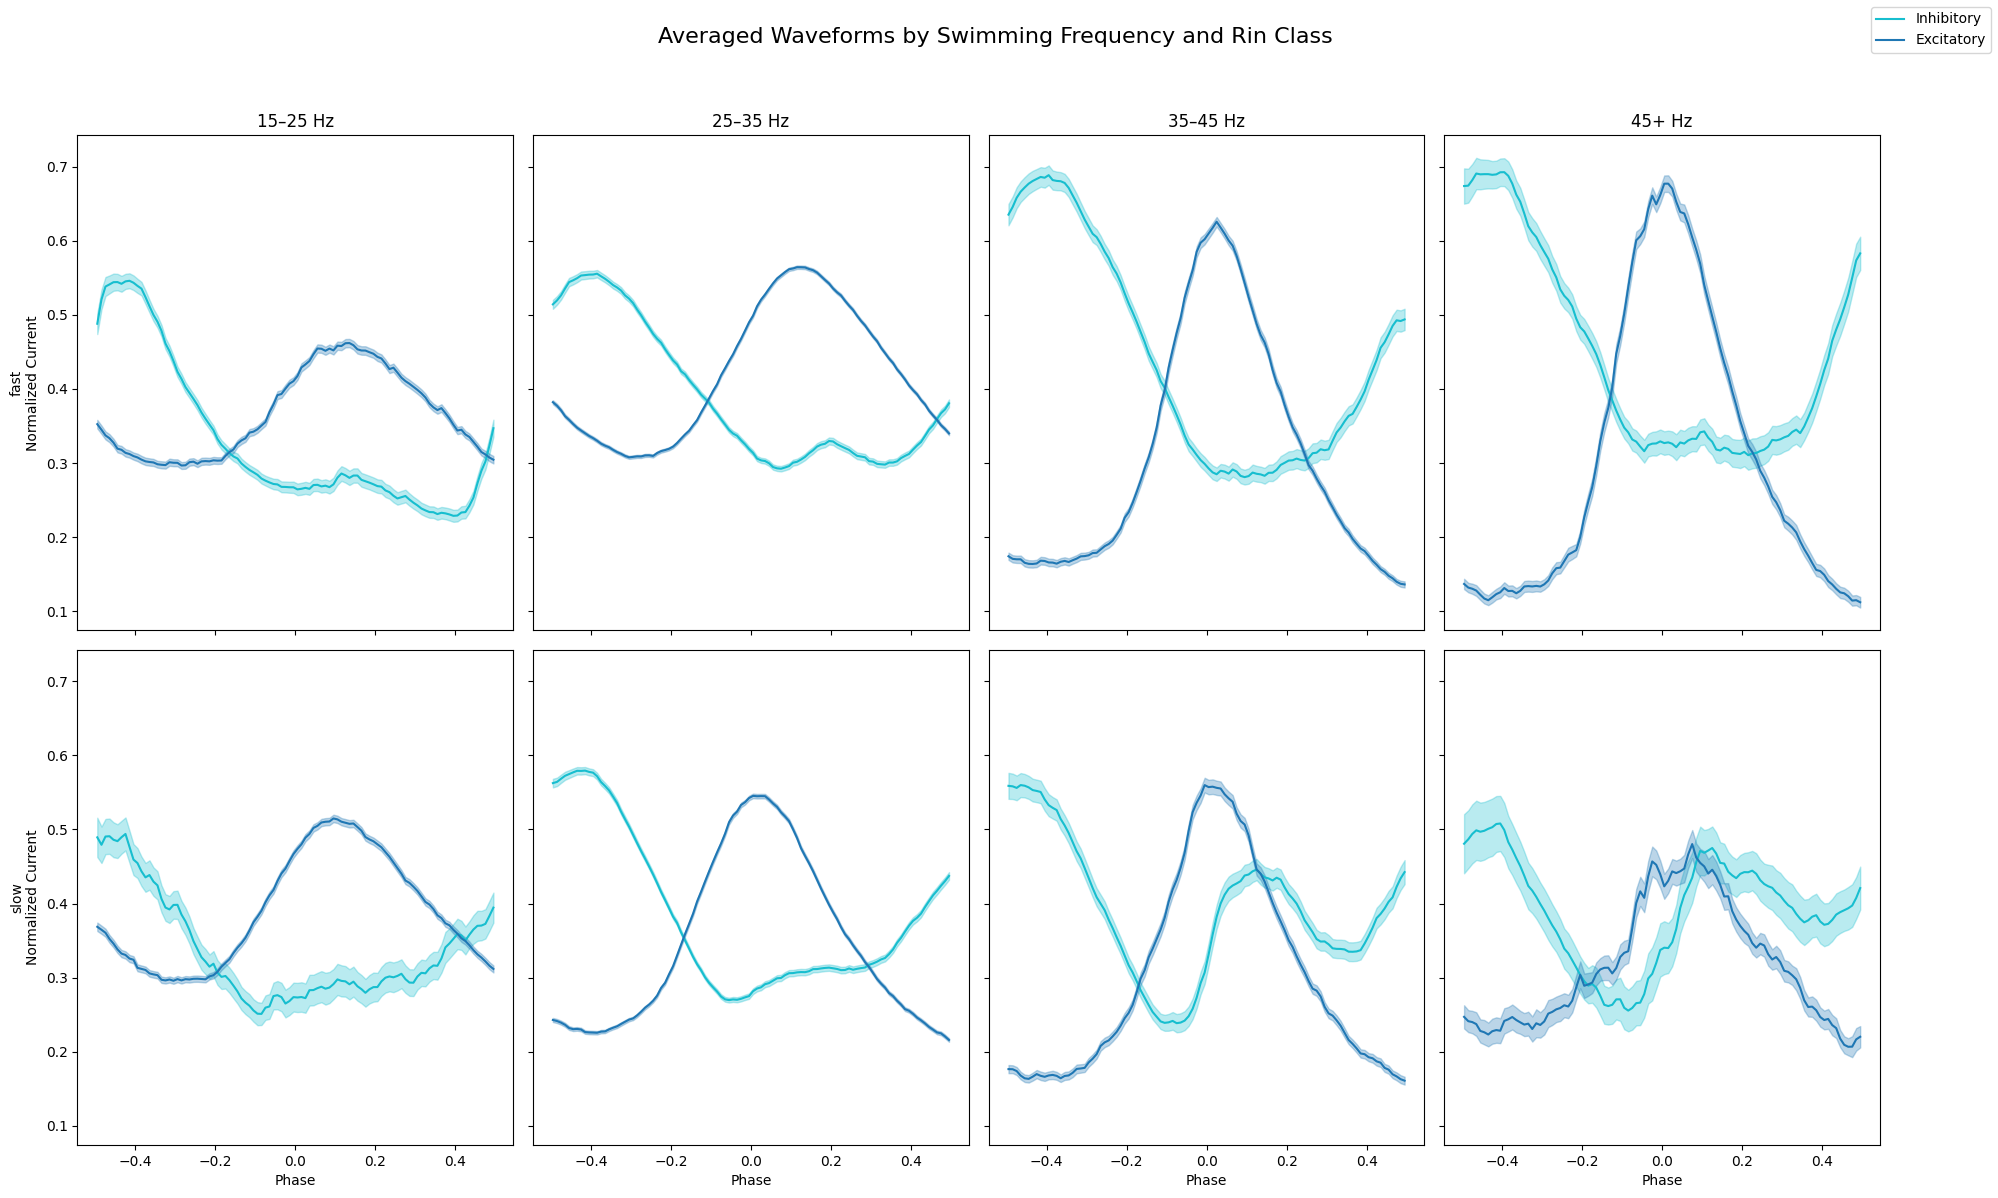

In [120]:
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# Frequency bins and swimming speed categories
freq_bins = ["15–25", "25–35", "35–45", "45+"]
speed_categories = ["fast", "slow"]
signal_types = ["Inhibitory", "Excitatory"]

# Assign unique colors to signal types
cmap = cm.get_cmap('tab10', len(signal_types))
signal_type_colors = {stype: cmap(i) for i, stype in enumerate(sorted(signal_types))}

# Create 3x4 subplots: rows = swimming speeds, columns = frequency bins
fig, axes = plt.subplots(len(speed_categories), len(freq_bins), figsize=(20, 12), sharex=True, sharey=True)

# Track which labels have been used to avoid duplicates in the legend
used_labels = set()
count = 0
# Loop through each combination of speed and frequency bin
avg_waveforms = []
for i, speed in enumerate(speed_categories):
    for j, freq_bin in enumerate(freq_bins):
        ax = axes[i, j]

        for signal_type in signal_types:
            # Construct the key without cell type
            # matching_keys = [key for key in binned_waveforms.keys()
            #                  if get_freq_bin(key[0]) == freq_bin and
            #                     key[1] == signal_type and
            #                     key[2] == speed]
            # dfs = [binned_waveforms[key].copy() for key in matching_keys]
            # if not dfs:
            #     continue
            # count += 1
            # combined = pd.concat(dfs)
            # grouped = combined.groupby('Phase Bin', observed=False)
            # averaged = grouped.mean().reset_index()
            # sem = grouped.sem().reset_index()
            counter_key = (freq_bin, signal_type, speed)
            averaged, sem = average_waveforms_for_key_invert(counter_key)
            averaged['freq bin'] = freq_bin
            averaged['signal type'] = signal_type
            averaged['speed population'] = speed
            avg_waveforms.append(averaged)

            if averaged is None:
                continue
            label = signal_type if signal_type not in used_labels else None
            ax.plot(averaged['Phase'], averaged['Normalized Current'],
                    label=label, color=signal_type_colors[signal_type])
            ax.fill_between(averaged['Phase'],
                            averaged['Normalized Current'] - sem['Normalized Current'],
                            averaged['Normalized Current'] + sem['Normalized Current'],
                            color=signal_type_colors[signal_type], alpha=0.3)
            used_labels.add(signal_type)

        # Add subplot title and labels
        if i == 0:
            ax.set_title(f"{freq_bin} Hz")
        if j == 0:
            ax.set_ylabel(f"{speed}\nNormalized Current")
        if i == len(speed_categories) - 1:
            ax.set_xlabel("Phase")

# Finalize layout and add legend to the figure
handles, labels = [], []
for stype in signal_types:
    handles.append(plt.Line2D([0], [0], color=signal_type_colors[stype]))
    labels.append(stype)
fig.legend(handles, labels, loc='upper right')
fig.suptitle("Averaged Waveforms by Swimming Frequency and Rin Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


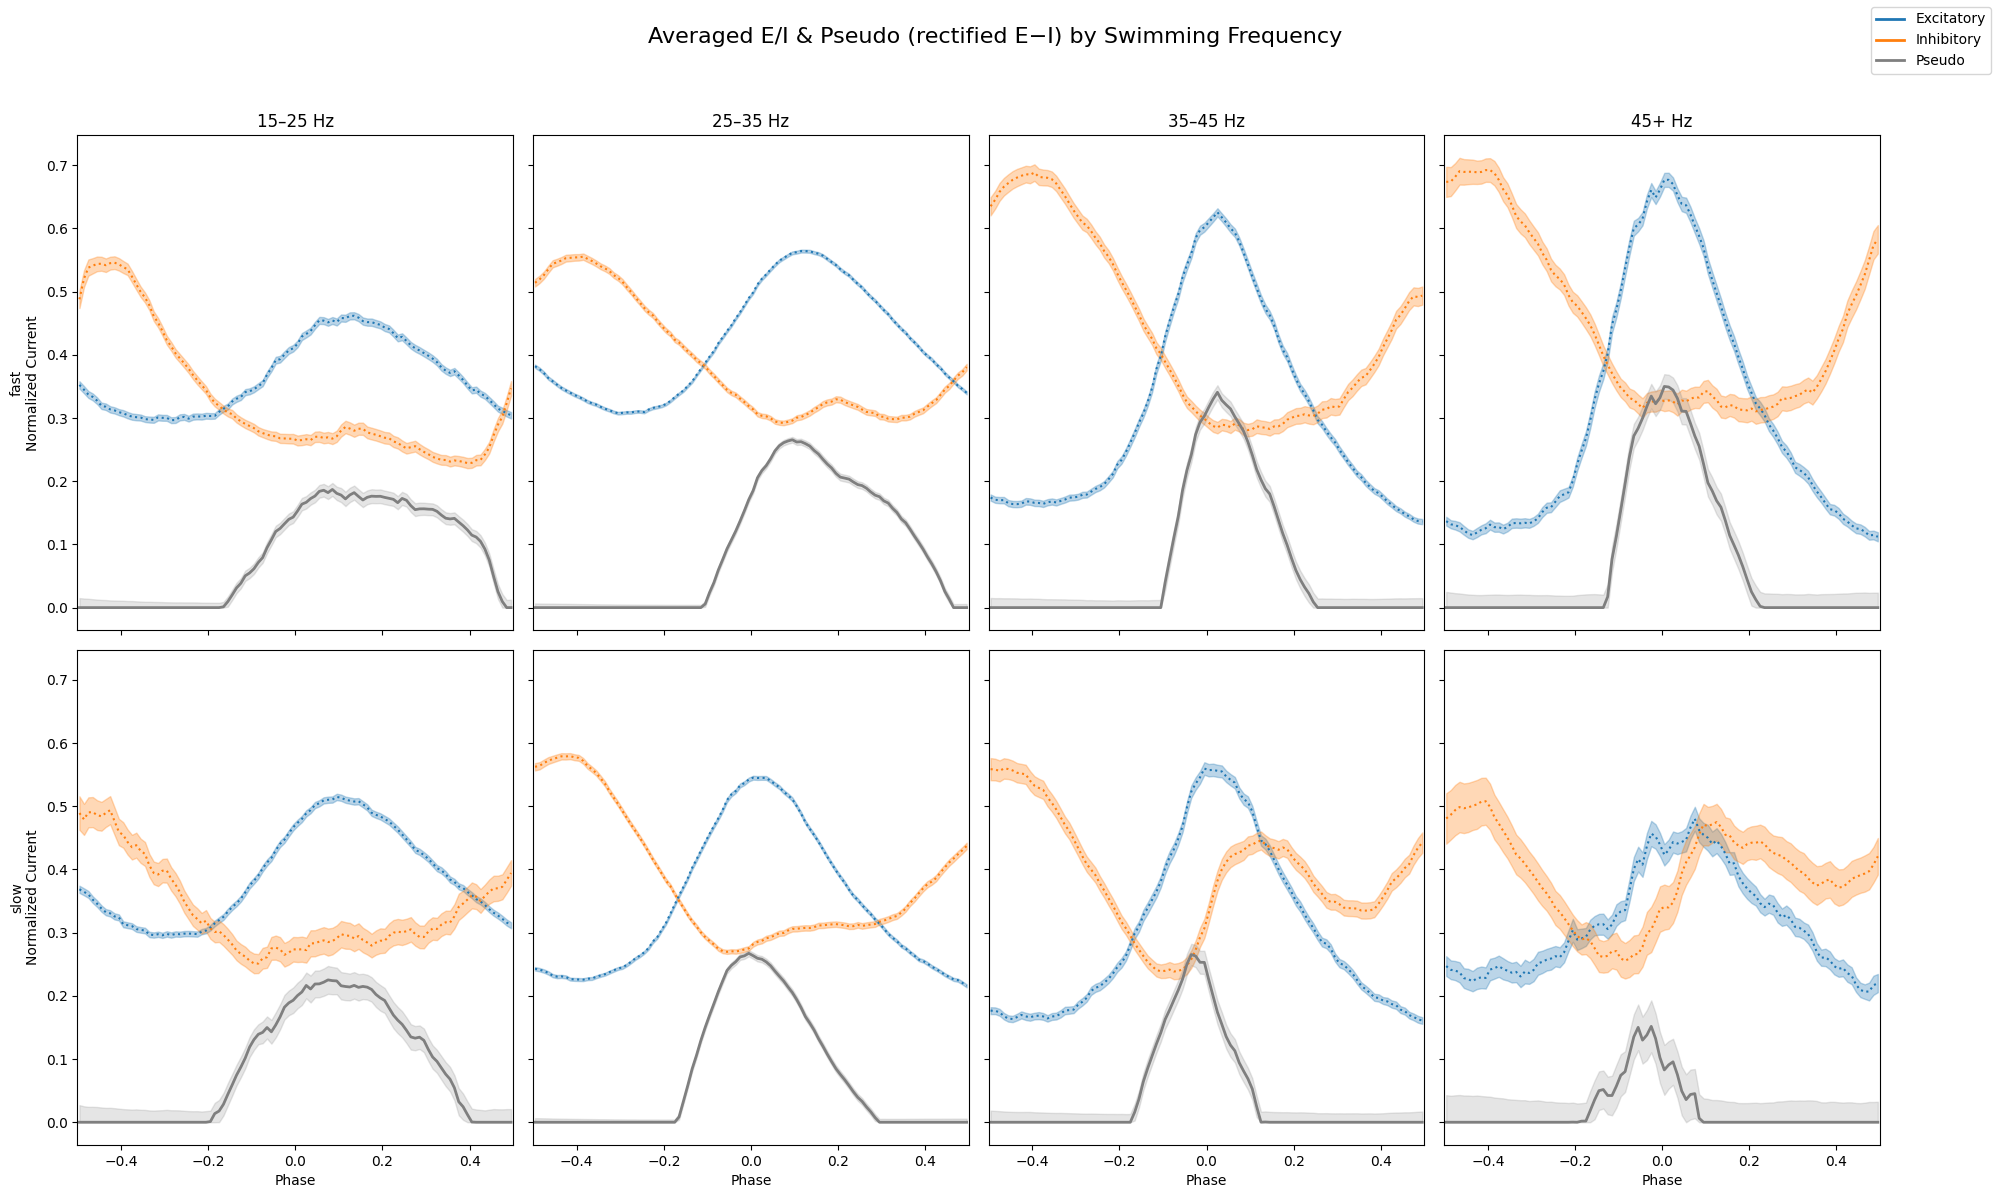

In [121]:
def plot_e_i_pseudo(
    average_func,
    freq_bins=("15–25", "25–35", "35–45", "45+"),
    speed_categories=("fast", "slow"),
    title="Averaged E/I & Pseudo (rectified E−I) by Swimming Frequency",
    show=True
):
    """
    Plot Excitatory, Inhibitory, and Pseudo (rectified E−I) currents using
    pre-averaged data returned by `average_func(counter_key)`.

    Colors:
      - Excitatory: tab:blue
      - Inhibitory: tab:orange
      - Pseudo: tab:gray
    """
    import matplotlib.pyplot as plt
    import numpy as np

    signal_type_colors = {
        "Excitatory": "tab:blue",
        "Inhibitory": "tab:orange",
        "Pseudo": "tab:gray"
    }

    fig, axes = plt.subplots(len(speed_categories), len(freq_bins),
                             figsize=(20, 12), sharex=True, sharey=True)

    used_labels = set()

    for i, speed in enumerate(speed_categories):
        for j, freq_bin in enumerate(freq_bins):
            ax = axes[i, j] if len(speed_categories) > 1 else axes[j]

            # --- get averaged E and I for this (speed, freq_bin) ---
            key_E = (freq_bin, "Excitatory", speed)
            key_I = (freq_bin, "Inhibitory", speed)

            avg_E, sem_E = average_func(key_E)
            avg_I, sem_I = average_func(key_I)

            if avg_E is None or avg_I is None:
                if i == 0:
                    ax.set_title(f"{freq_bin} Hz")
                if j == 0:
                    ax.set_ylabel(f"{speed}\nNormalized Current")
                if i == len(speed_categories) - 1:
                    ax.set_xlabel("Phase")
                continue

            # Align phase axes if needed
            phase_E = avg_E["Phase"].to_numpy()
            E = avg_E["Normalized Current"].to_numpy()
            E_sem = sem_E["Normalized Current"].to_numpy()

            phase_I_raw = avg_I["Phase"].to_numpy()
            I_raw = avg_I["Normalized Current"].to_numpy()
            I_sem_raw = sem_I["Normalized Current"].to_numpy()

            if (len(phase_E) != len(phase_I_raw)) or (not np.allclose(phase_E, phase_I_raw)):
                I = np.interp(phase_E, phase_I_raw, I_raw)
                I_sem = np.interp(phase_E, phase_I_raw, I_sem_raw)
                phase = phase_E
            else:
                phase = phase_I_raw
                I = I_raw
                I_sem = I_sem_raw

            # --- plot Excitatory and Inhibitory currents ---
            ax.plot(phase, E, label="Excitatory" if "Excitatory" not in used_labels else None,
                    color=signal_type_colors["Excitatory"], ls=':')
            ax.fill_between(phase, E - E_sem, E + E_sem,
                            color=signal_type_colors["Excitatory"], alpha=0.3)

            ax.plot(phase, I, label="Inhibitory" if "Inhibitory" not in used_labels else None,
                    color=signal_type_colors["Inhibitory"], ls=':')
            ax.fill_between(phase, I - I_sem, I + I_sem,
                            color=signal_type_colors["Inhibitory"], alpha=0.3)
            used_labels.update(["Excitatory", "Inhibitory"])

            # --- compute and plot Pseudo = rectified (E - I) ---
            pseudo = np.maximum(E - I, 0.0)
            pseudo_sem = np.sqrt(E_sem**2 + I_sem**2)  # conservative propagation
            pseudo_upper = np.maximum(pseudo + pseudo_sem, 0.0)
            pseudo_lower = np.maximum(pseudo - pseudo_sem, 0.0)

            ax.plot(phase, pseudo, label="Pseudo (rectified E−I)" if "Pseudo" not in used_labels else None,
                    color=signal_type_colors["Pseudo"], lw=2)
            ax.fill_between(phase, pseudo_lower, pseudo_upper,
                            color=signal_type_colors["Pseudo"], alpha=0.2)
            used_labels.add("Pseudo")

            # --- subplot labels ---
            if i == 0:
                ax.set_title(f"{freq_bin} Hz")
            if j == 0:
                ax.set_ylabel(f"{speed}\nNormalized Current")
            if i == len(speed_categories) - 1:
                ax.set_xlabel("Phase")
            ax.set_xlim(-0.5, 0.5)

    # Legend
    handles, labels = [], []
    for key in ["Excitatory", "Inhibitory", "Pseudo"]:
        handles.append(plt.Line2D([0], [0], color=signal_type_colors[key], lw=2))
        labels.append(key)
    fig.legend(handles, labels, loc='upper right')

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    if show:
        plt.show()

plot_e_i_pseudo(average_waveforms_for_key_invert)



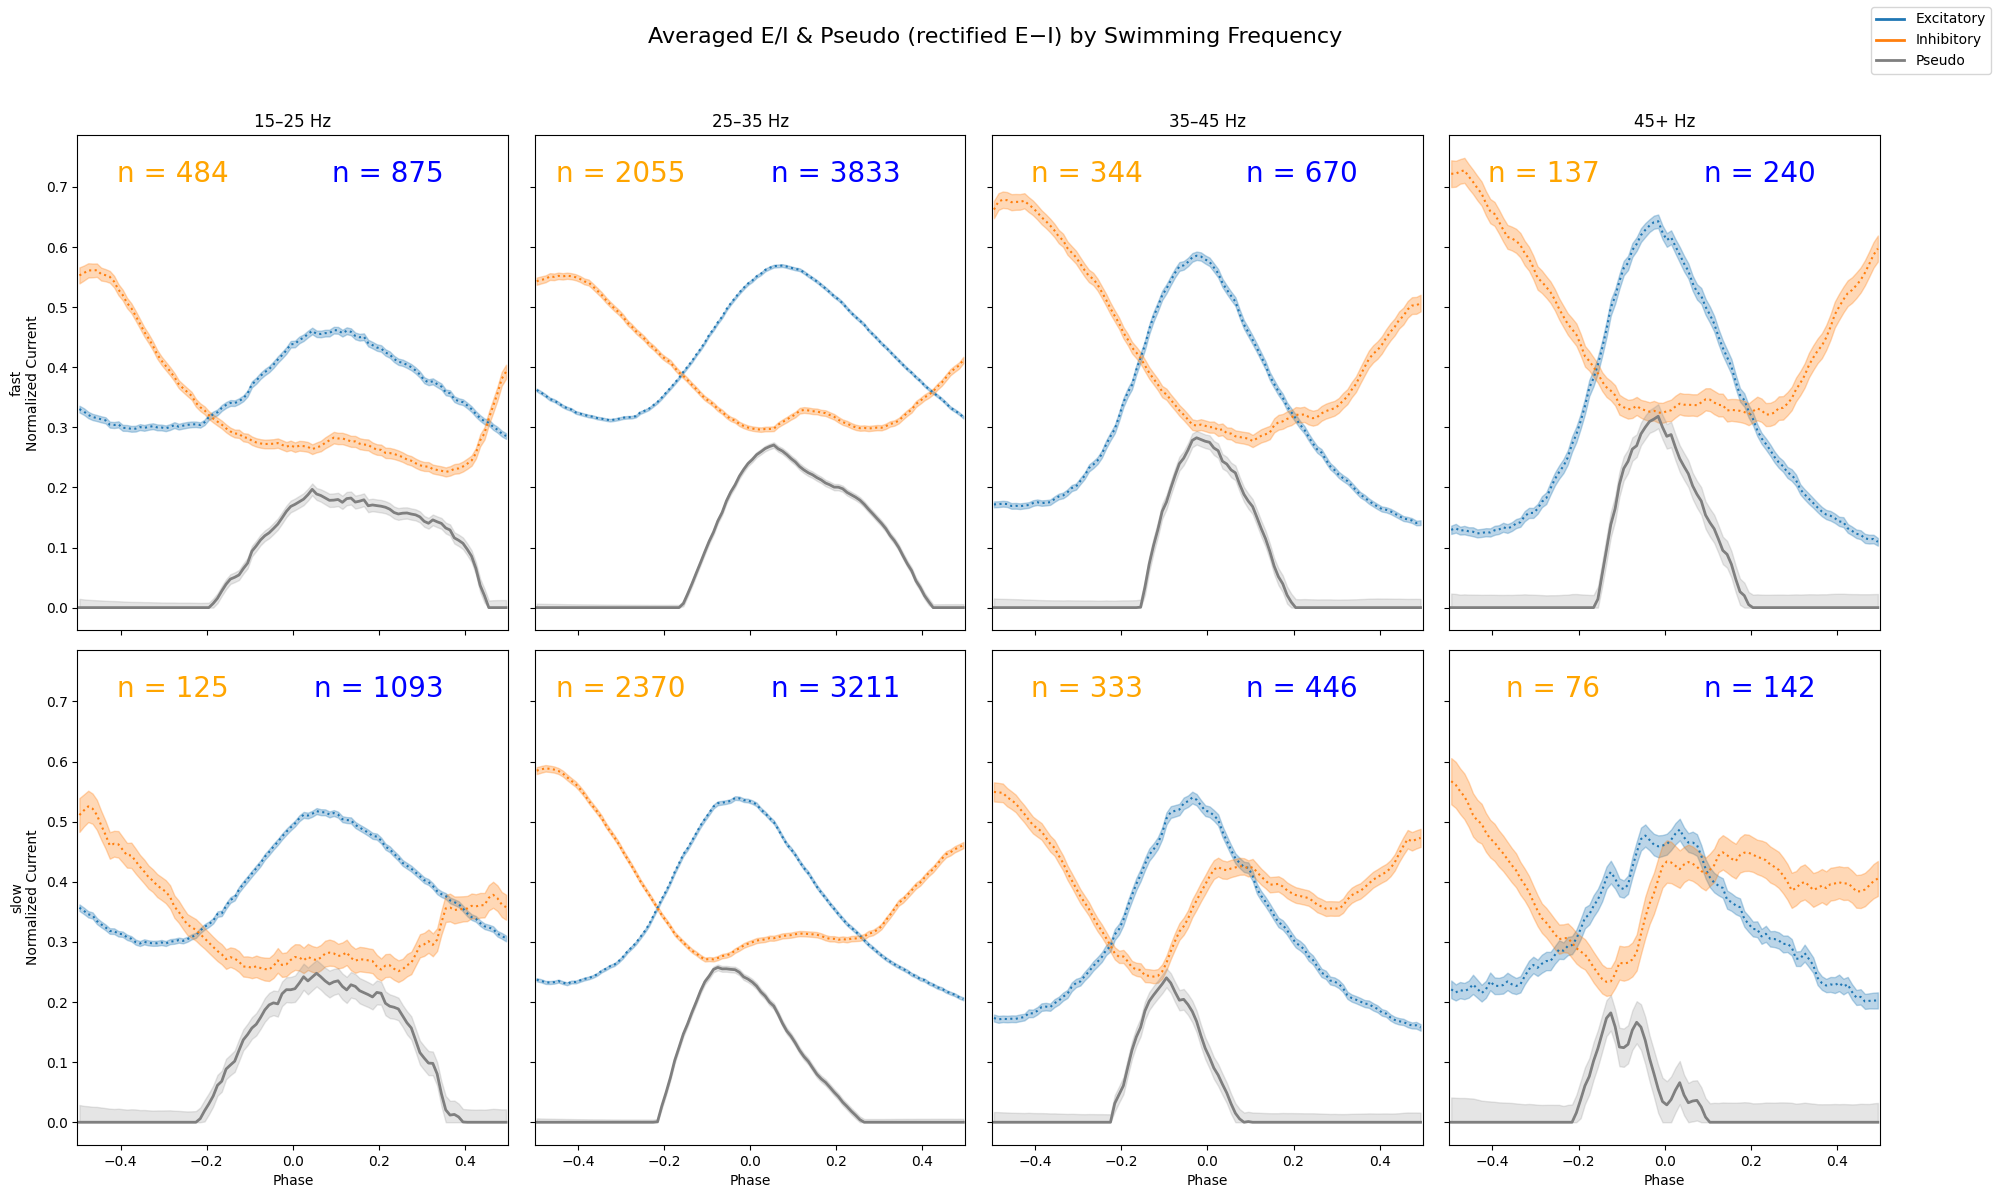

In [86]:
# Function definitions moved to finalwaveform_processor_functions.py\n

In [ ]:
key_counts

KeyboardInterrupt: 

/var/folders/mw/pz4gm95j6zb7syl48vm11wrw0000gn/T/ipykernel_44400/3018348576.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(signal_types) + 1)


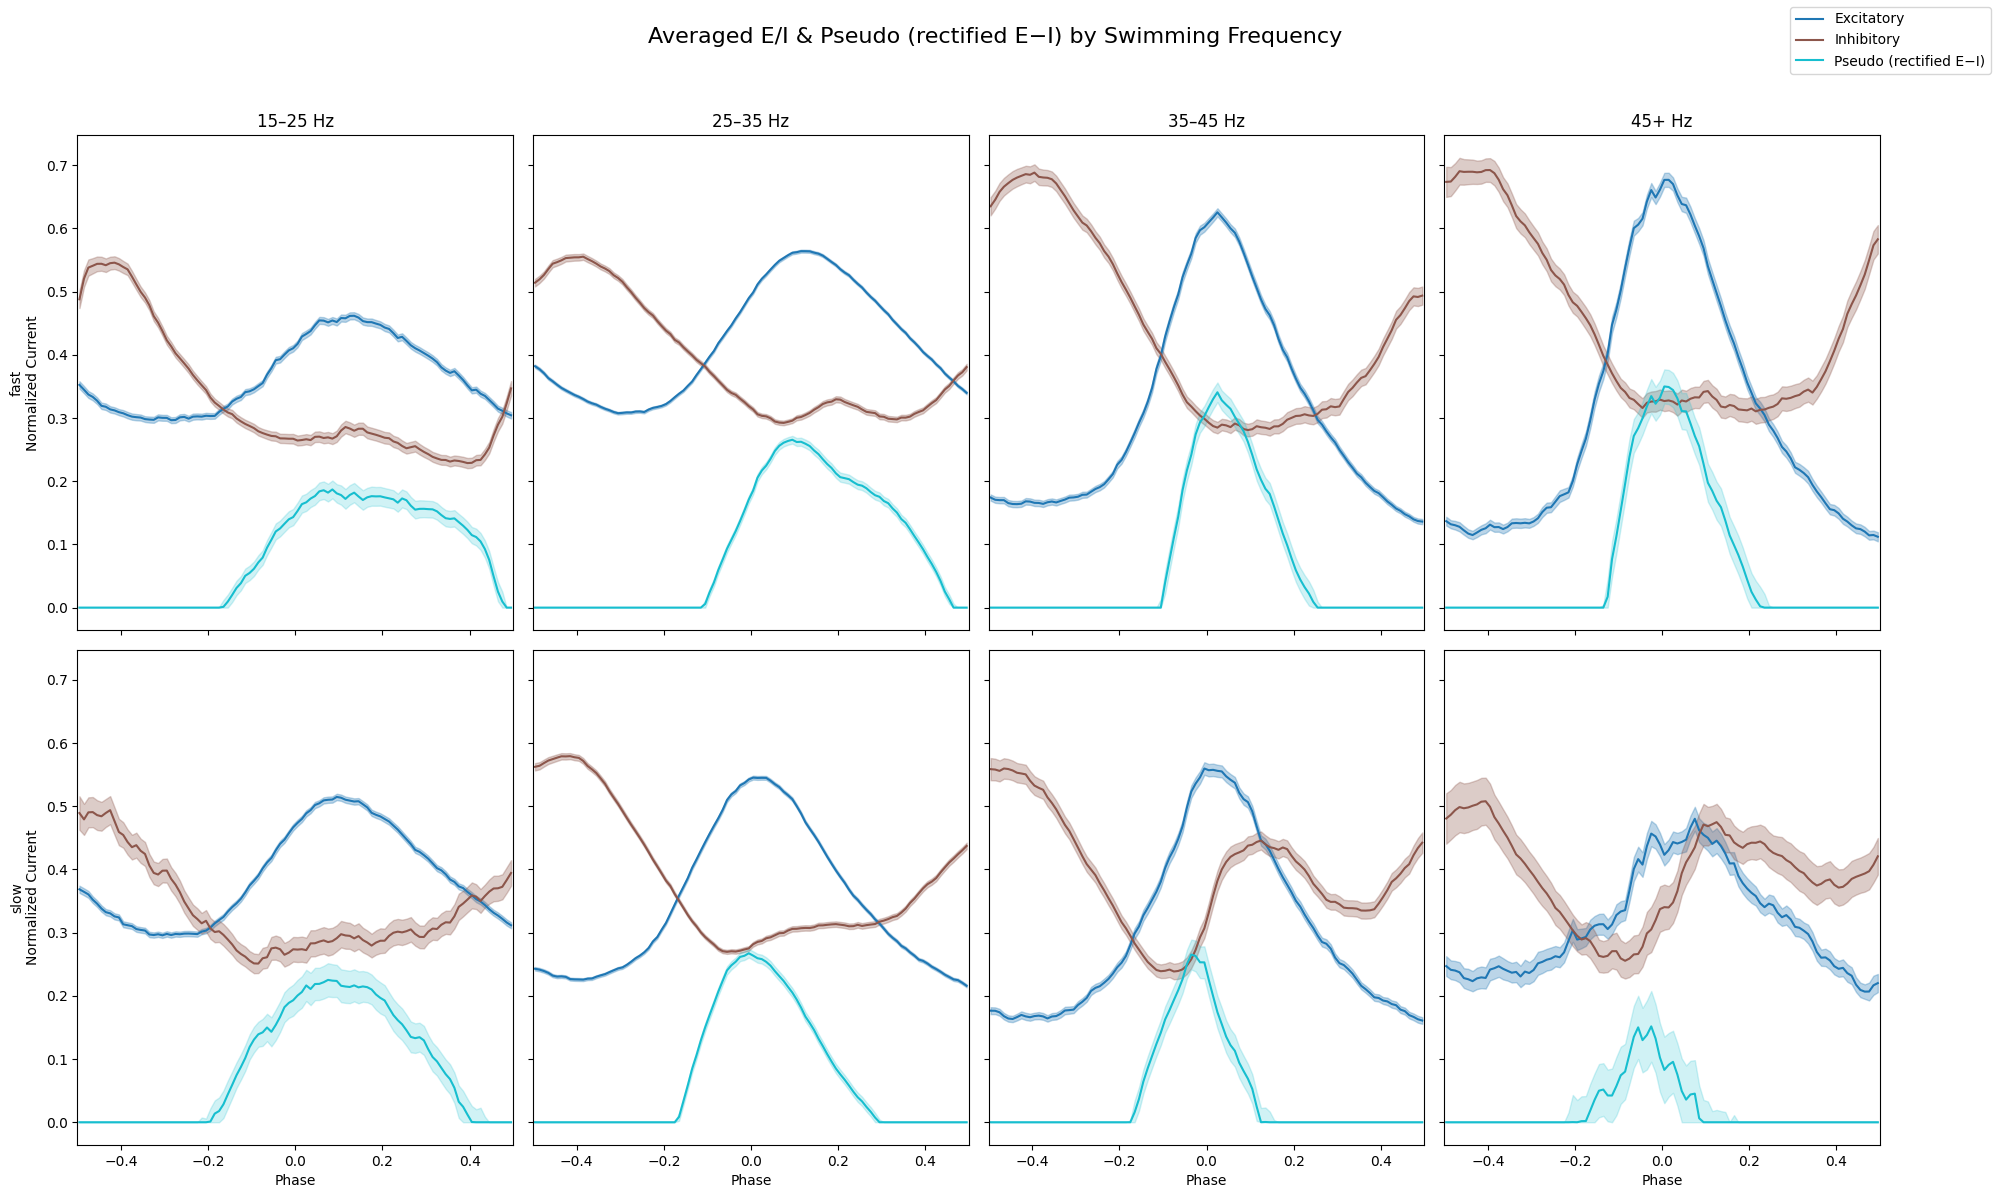

In [ ]:
# Function definitions moved to finalwaveform_processor_functions.py\n

In [87]:
avg =  pd.concat(avg_waveforms, ignore_index=True)

In [ ]:
avg.to_csv("averaged_waveforms_blackdot_only.csv", index=False)
print(f"Saved averaged waveforms to averaged_waveforms_blackdot_only.csv")

In [ ]:
avg

,Phase,Current,Normalized Current,freq bin,signal type,speed population
0,-0.4955,531.967163,0.487952,15–25,Inhibitory,fast
1,-0.4850,538.735291,0.520690,15–25,Inhibitory,fast
2,-0.4750,543.326599,0.538129,15–25,Inhibitory,fast
3,-0.4650,544.846313,0.540993,15–25,Inhibitory,fast
4,-0.4550,545.609863,0.544029,15–25,Inhibitory,fast
...,...,...,...,...,...,...
1595,0.4550,-56.478493,0.790620,45+,Excitatory,slow
1596,0.4650,-56.353317,0.793280,45+,Excitatory,slow
1597,0.4750,-56.935139,0.793147,45+,Excitatory,slow
1598,0.4850,-57.507530,0.783288,45+,Excitatory,slow


In [ ]:
key_counts

Counter({('25–35', 'Excitatory', 'fast'): 3876,
         ('25–35', 'Excitatory', 'slow'): 3247,
         ('25–35', 'Inhibitory', 'slow'): 2391,
         ('25–35', 'Inhibitory', 'fast'): 2086,
         ('15–25', 'Excitatory', 'slow'): 1067,
         ('15–25', 'Excitatory', 'fast'): 865,
         ('35–45', 'Excitatory', 'fast'): 645,
         ('15–25', 'Inhibitory', 'fast'): 470,
         ('35–45', 'Excitatory', 'slow'): 443,
         ('35–45', 'Inhibitory', 'fast'): 318,
         ('35–45', 'Inhibitory', 'slow'): 301,
         ('45+', 'Excitatory', 'fast'): 229,
         ('15–25', 'Inhibitory', 'slow'): 140,
         ('45+', 'Inhibitory', 'fast'): 138,
         ('45+', 'Excitatory', 'slow'): 123,
         ('45+', 'Inhibitory', 'slow'): 69})

In [ ]:
# Function definitions moved to finalwaveform_processor_functions.py\n

In [ ]:
# Function definitions moved to finalwaveform_processor_functions.py\n

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().